In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# from imblearn.combine import SMOTETomek

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

In [38]:
app = pd.read_csv('application_record.csv')
credit = pd.read_csv('credit_record.csv')
app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


Number of people working status :
OCCUPATION_TYPE
Laborers                 78240
Core staff               43007
Sales staff              41098
Managers                 35487
Drivers                  26090
High skill tech staff    17289
Accountants              15985
Medicine staff           13520
Cooking staff             8076
Security staff            7993
Cleaning staff            5845
Private service staff     3456
Low-skill Laborers        2140
Secretaries               2044
Waiters/barmen staff      1665
Realty agents             1041
HR staff                   774
IT staff                   604
Name: count, dtype: int64


C:\Users\SAI RAM\AppData\Local\Temp\ipykernel_15176\256944142.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='OCCUPATION_TYPE', data=app, palette='Set2')


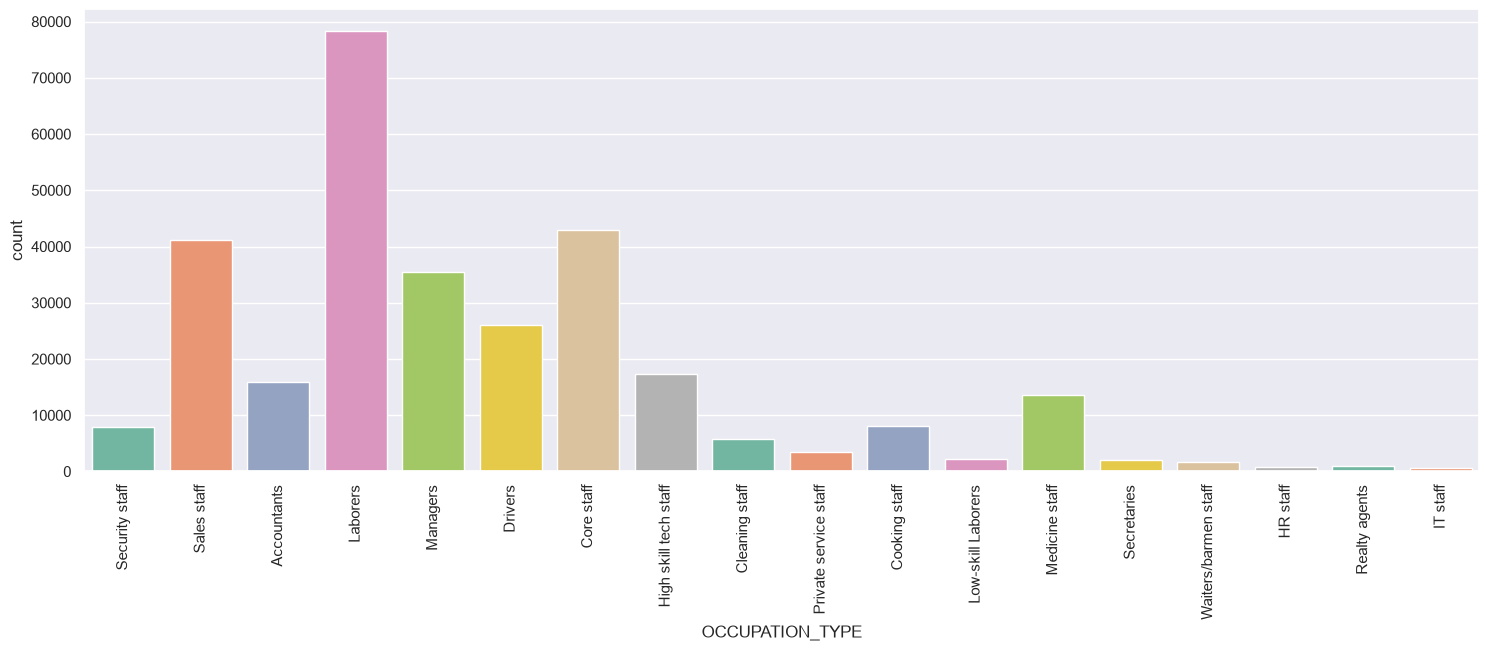

In [39]:
print("Number of people working status :")
print(app['OCCUPATION_TYPE'].value_counts())

sns.set(rc={'figure.figsize': (18,6)})

sns.countplot(x='OCCUPATION_TYPE', data=app, palette='Set2')
plt.xticks(rotation=90)
plt.show()

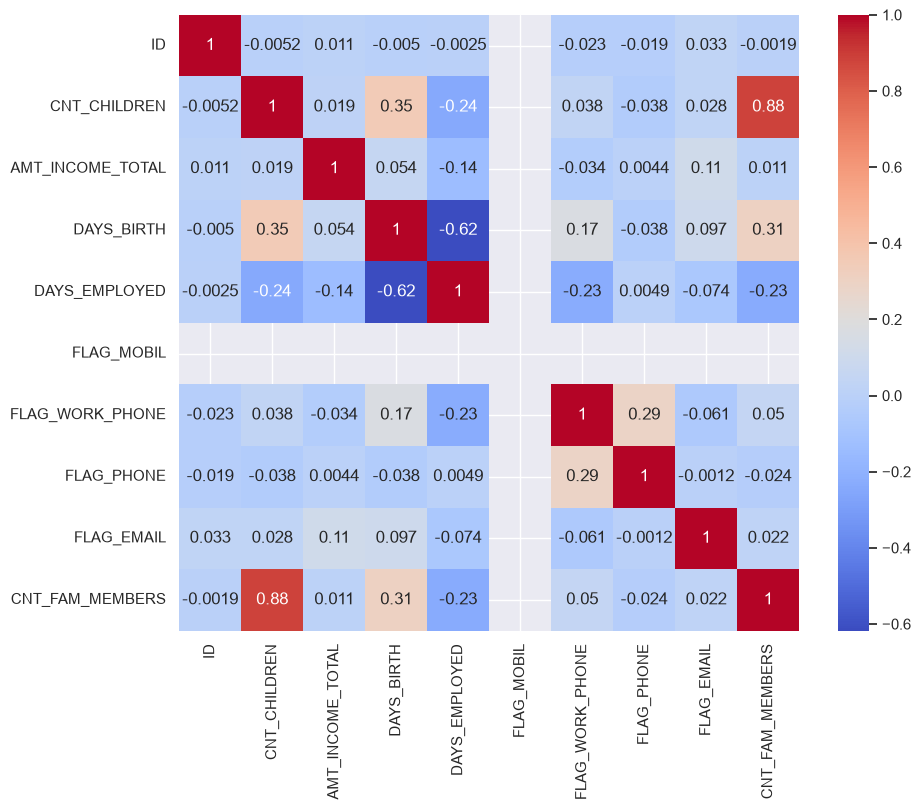

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
corr = app.select_dtypes(include=['number']).corr()

fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [41]:
app.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [42]:
# dropping duplicate rows

app.drop_duplicates(
    subset=[
        'CODE_GENDER',
        'FLAG_OWN_CAR',
        'FLAG_OWN_REALTY',
        'CNT_CHILDREN',
        'AMT_INCOME_TOTAL',
        'NAME_INCOME_TYPE',
        'NAME_EDUCATION_TYPE',
        'NAME_FAMILY_STATUS',
        'NAME_HOUSING_TYPE',
        'DAYS_BIRTH',
        'DAYS_EMPLOYED',
        'FLAG_MOBIL',
        'FLAG_WORK_PHONE',
        'FLAG_PHONE',
        'FLAG_EMAIL',
        'OCCUPATION_TYPE',
        'CNT_FAM_MEMBERS'
    ],
    keep='first',
    inplace=True
)

In [43]:
app.isnull().mean()

ID                     0.000000
CODE_GENDER            0.000000
FLAG_OWN_CAR           0.000000
FLAG_OWN_REALTY        0.000000
CNT_CHILDREN           0.000000
AMT_INCOME_TOTAL       0.000000
NAME_INCOME_TYPE       0.000000
NAME_EDUCATION_TYPE    0.000000
NAME_FAMILY_STATUS     0.000000
NAME_HOUSING_TYPE      0.000000
DAYS_BIRTH             0.000000
DAYS_EMPLOYED          0.000000
FLAG_MOBIL             0.000000
FLAG_WORK_PHONE        0.000000
FLAG_PHONE             0.000000
FLAG_EMAIL             0.000000
OCCUPATION_TYPE        0.305012
CNT_FAM_MEMBERS        0.000000
dtype: float64

In [44]:
import numpy as np

def data_cleaning(df):

    df = df.copy()

    # Remove duplicate records
    subset_cols = [
        'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
        'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
        'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
        'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
        'DAYS_BIRTH', 'DAYS_EMPLOYED',
        'FLAG_MOBIL', 'FLAG_WORK_PHONE',
        'FLAG_PHONE', 'FLAG_EMAIL',
        'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'
    ]

    subset_cols = [col for col in subset_cols if col in df.columns]

    print("Shape before removing duplicates:", df.shape)

    df.drop_duplicates(
        subset=subset_cols,
        keep='first',
        inplace=True
    )

    print("Shape after removing duplicates:", df.shape)

    # Missing values
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Drop Occupation Type
    if 'OCCUPATION_TYPE' in df.columns:
        df.drop(columns=['OCCUPATION_TYPE'], inplace=True)

    # Family Dependency
    df['FAMILY_DEPENDENCY'] = (
        df['CNT_CHILDREN'] +
        df['CNT_FAM_MEMBERS']
    )

    # Age in Years
    if 'DAYS_BIRTH' in df.columns:
        df['AGE_YEARS'] = (
            abs(df['DAYS_BIRTH']) / 365
        ).astype(int)

    # Replace placeholder in employment
    if 'DAYS_EMPLOYED' in df.columns:
        df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
        df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].fillna(0)
        df['DAYS_EMPLOYED'] = abs(df['DAYS_EMPLOYED'])

        df['YEARS_EMPLOYED'] = (
            df['DAYS_EMPLOYED'] / 365).round(2)

    # Drop unnecessary columns
    drop_cols = ['FLAG_MOBIL', 'DAYS_BIRTH']
    drop_cols = [col for col in drop_cols if col in df.columns]

    df.drop(columns=drop_cols, inplace=True)

    return df

In [45]:
app = data_cleaning(app)

print(app.head())
print(app.shape)

Shape before removing duplicates: (90085, 18)
Shape after removing duplicates: (90085, 18)

Missing Values:
ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
NAME_HOUSING_TYPE          0
DAYS_BIRTH                 0
DAYS_EMPLOYED              0
FLAG_MOBIL                 0
FLAG_WORK_PHONE            0
FLAG_PHONE                 0
FLAG_EMAIL                 0
OCCUPATION_TYPE        27477
CNT_FAM_MEMBERS            0
dtype: int64
         ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0   5008804           M            Y               Y             0   
2   5008806           M            Y               Y             0   
3   5008808           F            N               Y             0   
7   5008812           F            N               Y             0   
10  500

In [46]:
# Convert Status to Binary
def to_binary(status):
    if status in ['0', 'X', 'C']:
        return 1
    else:
        return 0

credit['STATUS_BIN'] = credit['STATUS'].apply(to_binary)

print(credit['STATUS_BIN'].value_counts())

# Merge
final_df = app.merge(
    credit,
    how='left',
    on='ID'
)

print(f"Merged shape: {final_df.shape}")

print(final_df.head())

print("\nMissing values in each column:")
print(final_df.isnull().sum().sort_values(ascending=False))

STATUS_BIN
1    1034381
0      14194
Name: count, dtype: int64
Merged shape: (299549, 21)
        ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804           M            Y               Y             0   
1  5008804           M            Y               Y             0   
2  5008804           M            Y               Y             0   
3  5008804           M            Y               Y             0   
4  5008804           M            Y               Y             0   

   AMT_INCOME_TOTAL NAME_INCOME_TYPE NAME_EDUCATION_TYPE NAME_FAMILY_STATUS  \
0          427500.0          Working    Higher education     Civil marriage   
1          427500.0          Working    Higher education     Civil marriage   
2          427500.0          Working    Higher education     Civil marriage   
3          427500.0          Working    Higher education     Civil marriage   
4          427500.0          Working    Higher education     Civil marriage   

  NAME_HOUSING_TYPE 

In [47]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder objects
cg = LabelEncoder()
oc = LabelEncoder()
own_r = LabelEncoder()
it = LabelEncoder()
et = LabelEncoder()
fs = LabelEncoder()
ht = LabelEncoder()

# Apply Label Encoding
final_df['CODE_GENDER'] = cg.fit_transform(final_df['CODE_GENDER'])

final_df['FLAG_OWN_CAR'] = oc.fit_transform(final_df['FLAG_OWN_CAR'])

final_df['FLAG_OWN_REALTY'] = own_r.fit_transform(final_df['FLAG_OWN_REALTY'])

final_df['NAME_INCOME_TYPE'] = it.fit_transform(final_df['NAME_INCOME_TYPE'])

final_df['NAME_EDUCATION_TYPE'] = et.fit_transform(final_df['NAME_EDUCATION_TYPE'])

final_df['NAME_FAMILY_STATUS'] = fs.fit_transform(final_df['NAME_FAMILY_STATUS'])

final_df['NAME_HOUSING_TYPE'] = ht.fit_transform(final_df['NAME_HOUSING_TYPE'])

print("Label Encoding Completed Successfully!")
print(final_df.head())

Label Encoding Completed Successfully!
        ID  CODE_GENDER  FLAG_OWN_CAR  FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804            1             1                1             0   
1  5008804            1             1                1             0   
2  5008804            1             1                1             0   
3  5008804            1             1                1             0   
4  5008804            1             1                1             0   

   AMT_INCOME_TOTAL  NAME_INCOME_TYPE  NAME_EDUCATION_TYPE  \
0          427500.0                 4                    1   
1          427500.0                 4                    1   
2          427500.0                 4                    1   
3          427500.0                 4                    1   
4          427500.0                 4                    1   

   NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  ...  FLAG_WORK_PHONE  FLAG_PHONE  \
0                   0                  4  ...                1           0   

In [48]:
from sklearn.model_selection import train_test_split

X = final_df.drop(['ID', 'STATUS', 'STATUS_BIN'], axis=1)
y = final_df['STATUS_BIN']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(239639, 18)
(59910, 18)


In [49]:
print(final_df.columns.tolist())

['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_EMPLOYED', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'FAMILY_DEPENDENCY', 'AGE_YEARS', 'YEARS_EMPLOYED', 'MONTHS_BALANCE', 'STATUS', 'STATUS_BIN']


In [50]:
print(final_df.isnull().sum())

ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
NAME_HOUSING_TYPE          0
DAYS_EMPLOYED              0
FLAG_WORK_PHONE            0
FLAG_PHONE                 0
FLAG_EMAIL                 0
CNT_FAM_MEMBERS            0
FAMILY_DEPENDENCY          0
AGE_YEARS                  0
YEARS_EMPLOYED             0
MONTHS_BALANCE         80376
STATUS                 80376
STATUS_BIN             80376
dtype: int64


In [51]:
# Remove rows that have missing target values
final_df = final_df.dropna(subset=['STATUS_BIN'])

# Fill any remaining missing values in the feature columns
final_df = final_df.fillna(0)

# Check again
print(final_df.isnull().sum())

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_EMPLOYED          0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
CNT_FAM_MEMBERS        0
FAMILY_DEPENDENCY      0
AGE_YEARS              0
YEARS_EMPLOYED         0
MONTHS_BALANCE         0
STATUS                 0
STATUS_BIN             0
dtype: int64


In [60]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Features and Target
X = final_df.drop(['ID', 'STATUS', 'STATUS_BIN'], axis=1)
y = final_df['STATUS_BIN']

# Balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(y_resampled.value_counts())

# Split the balanced dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

STATUS_BIN
1.0    215418
0.0    215418
Name: count, dtype: int64
(344668, 18)
(86168, 18)


Initializing Logistic Regression classifier...
Training the Logistic Regression model on training data...


c:\Users\SAI RAM\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Generating predictions on the unseen test dataset...

----- Model Evaluation Results -----

Confusion Matrix
[[26052 17037]
 [16265 26814]]


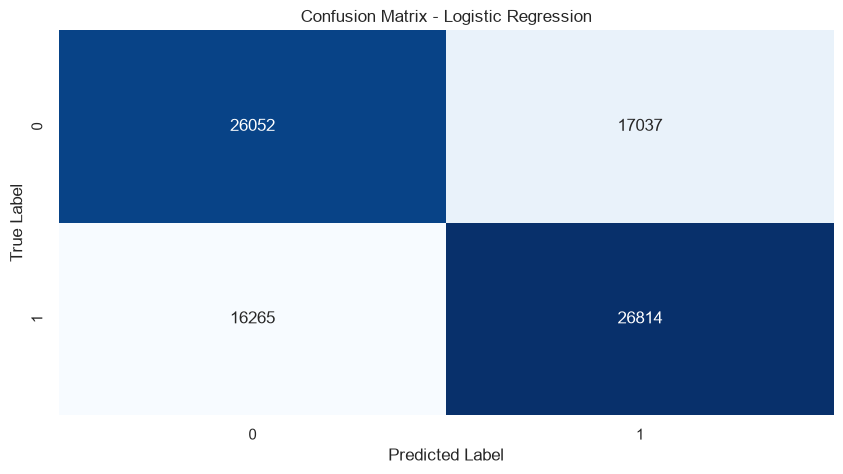


Classification Report
              precision    recall  f1-score   support

         0.0       0.62      0.60      0.61     43089
         1.0       0.61      0.62      0.62     43079

    accuracy                           0.61     86168
   macro avg       0.61      0.61      0.61     86168
weighted avg       0.61      0.61      0.61     86168



In [61]:
from logistic_regression_model import logistic_reg

model = logistic_reg(X_train, X_test, y_train, y_test)


Training Random Forest model...
Generating predictions...

Random Forest Model Evaluation

Confusion Matrix

[[42482   607]
 [  662 42417]]


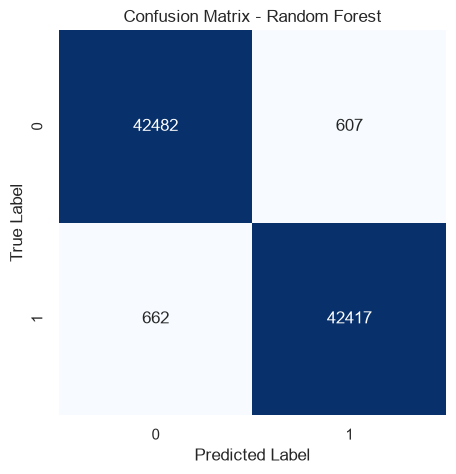


Classification Report

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99     43089
         1.0       0.99      0.98      0.99     43079

    accuracy                           0.99     86168
   macro avg       0.99      0.99      0.99     86168
weighted avg       0.99      0.99      0.99     86168



In [67]:
from random_forest_model import random_forest

model = random_forest(X_train, X_test, y_train, y_test)

In [56]:
import importlib
import decision_tree_model

importlib.reload(decision_tree_model)

from decision_tree_model import d_tree

***** Decision Tree Classifier *****
Confusion Matrix
[[  354   398]
 [  497 42586]]


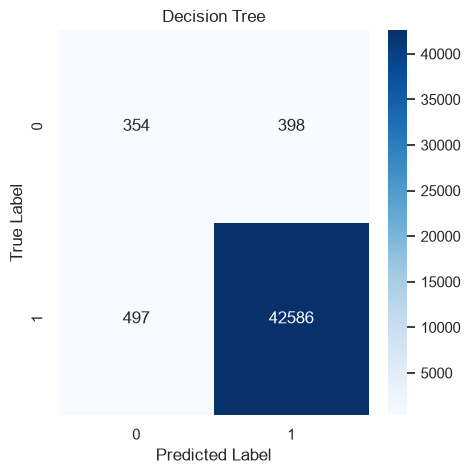

Classification Report
              precision    recall  f1-score   support

         0.0       0.42      0.47      0.44       752
         1.0       0.99      0.99      0.99     43083

    accuracy                           0.98     43835
   macro avg       0.70      0.73      0.72     43835
weighted avg       0.98      0.98      0.98     43835



,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [57]:
d_tree(X_train, X_test, y_train, y_test)

In [66]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

print("Random Forest model saved!")

Random Forest model saved!
